In [321]:
import pandas as pd 
import numpy as np 
import tensorflow as tf 

### Pre-Processing Data

In [322]:
data = pd.read_csv("train.csv")

In [323]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [324]:
data.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [325]:
data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [326]:
data = data.drop(['Id','Neighborhood'],axis=1)

In [327]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Condition1     1460 non-null   object 
 12  Condition2     1460 non-null   object 
 13  BldgType       1460 non-null   object 
 14  HouseStyle     1460 non-null   object 
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemo

### Split Data For Train Plus cleaning Data Onehot Encoding

In [328]:
# use xgboost to find with column is the most importance
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
X = data.drop('SalePrice',axis=1)
y = data['SalePrice']

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [329]:
#Care missing value
from sklearn.impute import SimpleImputer

#  1. แยก column
num_cols = X_train.select_dtypes(include=np.number).columns # เลือก column ที่เป็น ตัวเลข
cat_cols = X_train.select_dtypes(exclude=np.number).columns # เลือก column ที่ ไม่ใช่ตัวเลข (string / categorical)

#  2. สร้าง imputer แยก
num_imputer = SimpleImputer(strategy='median') # ถ้ามี missing  เติมค่า “กลาง”
cat_imputer = SimpleImputer(strategy='most_frequent')  # สำหรับ categorical เติมค่าที่ “เจอบ่อยที่สุด”

#  3. fit เฉพาะ train
num_imputer.fit(X_train[num_cols])
cat_imputer.fit(X_train[cat_cols])

#  4. transform
X_train[num_cols] = num_imputer.transform(X_train[num_cols])
X_train[cat_cols] = cat_imputer.transform(X_train[cat_cols])

#  5. ใช้กับ test ด้วย 
X_test[num_cols] = num_imputer.transform(X_test[num_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

In [330]:
X_train.isnull().sum()

MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
                ..
MiscVal          0
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
Length: 78, dtype: int64

In [331]:
X_train.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces',
       'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish',
       'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive',
       'WoodDeckSF', 'Open

In [332]:
# Onehot Encoding string => Number
from sklearn.compose import ColumnTransformer # การ แปลงตัวแปรอิสระ (X) ที่เป็นข้อความ (categorical) ให้กลายเป็น ตัวเลข เพื่อให้โมเดลเข้าใจได้
from sklearn.preprocessing import OneHotEncoder
cat_cols = X_train.select_dtypes(exclude=np.number).columns
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(handle_unknown='ignore'),cat_cols)], remainder='passthrough')
X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

In [333]:
''''
# Standard Scaler 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
# apply กับ test
X_test = scaler.transform(X_test)
'''

"'\n# Standard Scaler \nfrom sklearn.preprocessing import StandardScaler\n\nscaler = StandardScaler()\nX_train = scaler.fit_transform(X_train)\n# apply กับ test\nX_test = scaler.transform(X_test)\n"

In [334]:
model = XGBRegressor()
model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [335]:
#Predict Test Result
y_pred = model.predict(X_test)

# 
from sklearn.metrics import mean_absolute_error , mean_squared_error
    
mae = mean_absolute_error(y_test, y_pred)
print(mae)

17194.36657213185


In [336]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

25871.658111604516


### TRY IMPORTANCE FEATURE FROM XGBOOST TRAIN IN ANN

In [337]:
# Find feature that have the most weight 
feature_names = ct.get_feature_names_out() # ใช้เพราะมี One-hot encoding แตก column ใหม่
importance = pd.Series(model.feature_importances_, index=feature_names)
importance = importance.sort_values(ascending=False)
print(importance.head(20)) # ดูว่าตัวไหนน่าใช้แล้วเอาcolumn กลับไป train ใหม่อีกรอบ

remainder__OverallQual        0.394507
encoder__GarageFinish_Unf     0.087767
encoder__GarageType_Detchd    0.052670
remainder__GarageCars         0.049466
encoder__BsmtQual_Ex          0.044460
remainder__GrLivArea          0.035143
encoder__CentralAir_N         0.028915
encoder__KitchenQual_Ex       0.016705
encoder__LandContour_Bnk      0.014634
encoder__ExterQual_Ex         0.014427
remainder__TotalBsmtSF        0.013082
remainder__KitchenAbvGr       0.011186
encoder__RoofMatl_CompShg     0.010319
remainder__2ndFlrSF           0.010168
remainder__TotRmsAbvGrd       0.009025
encoder__SaleType_New         0.008923
encoder__MSZoning_RM          0.008867
encoder__Functional_Typ       0.008623
remainder__Fireplaces         0.008555
remainder__BsmtFinSF1         0.008412
dtype: float32


In [338]:
# Bring importance feature to use in ANN 
selected_features =  importance.head(20).index
# Convert arry to dataframe
X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)
# selected Feature
X_train_selected = X_train_df[selected_features]
X_test_selected = X_test_df[selected_features]

In [339]:
# Standard Scaler 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_selected = scaler.fit_transform(X_train_selected)
# apply กับ test
X_test_selected = scaler.transform(X_test_selected)

In [340]:
# For importance Feature
ann = tf.keras.models.Sequential() 

In [341]:
# Add input layer and first hidden layer เราต้องลองไปเรื่อยๆว่าhiden neuronไหนดีที่สุด relu rectifier activation 
# ANN Importance Feature 
ann.add(tf.keras.layers.Dense(128, activation='relu', input_dim=X_train_selected.shape[1]))
# second layer
ann.add(tf.keras.layers.Dense(64, activation='relu'))
# Third Layer
ann.add(tf.keras.layers.Dense(32, activation='relu'))
# Output
ann.add(tf.keras.layers.Dense(units=1))
#Compiling ANN regression
ann.compile(optimizer='adam', loss='mse', metrics=['mae'])


c:\Users\Ittikorn\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [342]:
ann.fit(X_train_selected,y_train,batch_size=32,epochs=100)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 38884442112.0000 - mae: 181438.6719   
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 38871617536.0000 - mae: 181409.0312 
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 38786383872.0000 - mae: 181224.2812 
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 38434607104.0000 - mae: 180489.9062 
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 37406244864.0000 - mae: 178364.0781 
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 35042570240.0000 - mae: 173403.9531 
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 30765223936.0000 - mae: 163844.5625 
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 24614772736.0000 - mae: 148365.6250 
Epoch 9/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 17792516096.0000 - mae: 126755.4219 
Epoch 10/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 12394553344.0000 - mae: 102985.0625 
Epoch 11/100
37/37 ━━━━━━━━━━━━━━━━━━

### ALL FEATURE ANN

In [343]:
ann_allfeature = tf.keras.models.Sequential() # For all Feature

In [344]:
# Add input layer and first hidden layer
ann_allfeature.add(tf.keras.layers.Dense(128,activation='relu',input_dim=X_train.shape[1]))
# Second Layer
ann_allfeature.add(tf.keras.layers.Dense(64, activation='relu'))
# thrid Layer
ann_allfeature.add(tf.keras.layers.Dense(32, activation='relu'))
# Output
ann_allfeature.add(tf.keras.layers.Dense(units=1))
# Compile Regression
ann_allfeature.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [345]:
ann_allfeature.fit(X_train,y_train,batch_size=32,epochs=100)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 37205651456.0000 - mae: 177068.1875
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 22625492992.0000 - mae: 126935.8750
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7570165760.0000 - mae: 50107.3516
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5776960512.0000 - mae: 44641.0469
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4730888704.0000 - mae: 42925.2148
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4145441024.0000 - mae: 42868.8242
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3769278720.0000 - mae: 40635.3789
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3386538496.0000 - mae: 39523.6133
Epoch 9/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3145387520.0000 - mae: 38919.6289
Epoch 10/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2967288320.0000 - mae: 37684.5742
Epoch 11/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 27696

In [346]:
#Predict Test Result
#Importance Feature
print('IMPORTANCE FEATURE')
y_pred = ann.predict(X_test_selected)
print(y_pred[:5])
print('---------------------')
#ALL Feature
print("ALL FEATURE")
y_pred_allfeature = ann_allfeature.predict(X_test)
print(y_pred_allfeature[:5])

IMPORTANCE FEATURE
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
[[149677.03]
 [333189.97]
 [108302.34]
 [175873.78]
 [332391.38]]
---------------------
ALL FEATURE
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[[140741.38]
 [334133.72]
 [116092.54]
 [173442.81]
 [273320.66]]


In [347]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mae1 = mean_absolute_error(y_test, y_pred_allfeature)
rmse1 = np.sqrt(mean_squared_error(y_test, y_pred_allfeature))
print('IMPORTANCE FEATURE')
print("MAE:", mae)
print("RMSE:", rmse)
print('---------------')
print("ALL FEATURE")
print("MAE_Allfeature:", mae1)
print("RMSE_AllFeature:", rmse1)

IMPORTANCE FEATURE
MAE: 21730.80583797089
RMSE: 35454.73538398908
---------------
ALL FEATURE
MAE_Allfeature: 23470.98240849743
RMSE_AllFeature: 37556.08316958278


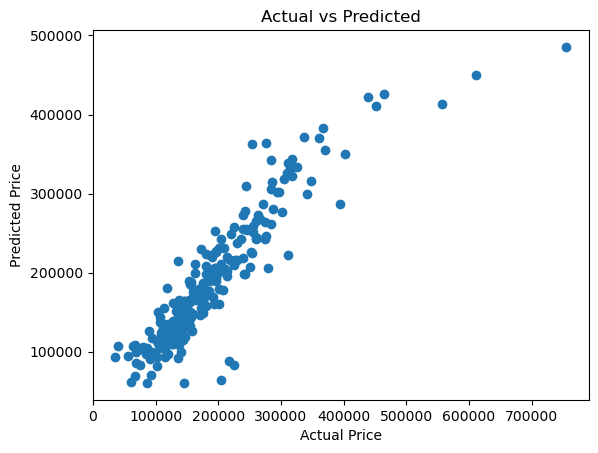

In [348]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


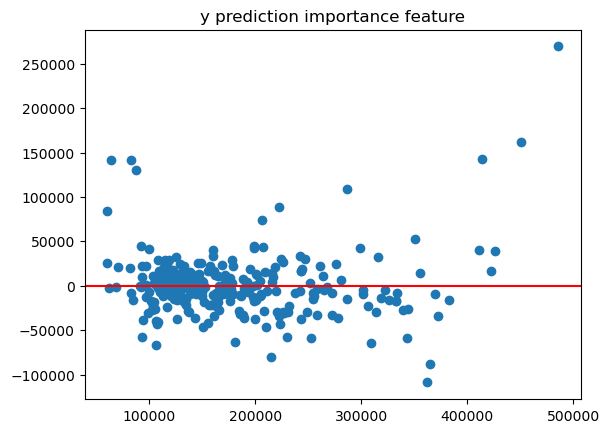

In [349]:
y_pred = ann.predict(X_test_selected).flatten()
y_test_1d = y_test.values.flatten()
plt.scatter(y_pred, y_test_1d - y_pred)
plt.axhline(0, color='red')
plt.title("y prediction importance feature")
plt.show()

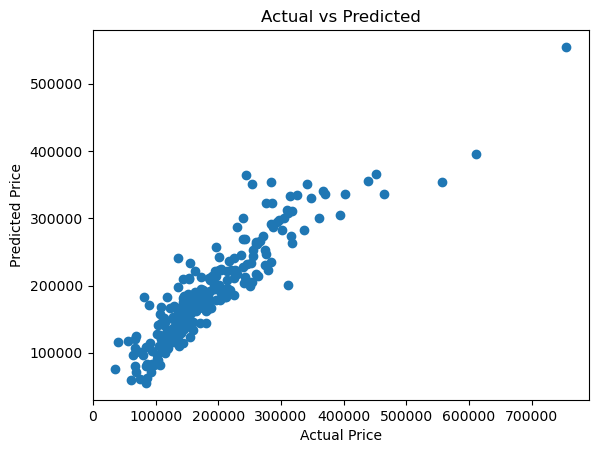

In [350]:
# ALL Feature
plt.scatter(y_test, y_pred_allfeature)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [351]:

#เอาค่าจริง (y_test) กับค่าที่โมเดลทำนาย (y_pred) มาเทียบกันในตารางเดียว
result = pd.DataFrame({"y_true": y_test, "y_pred": y_pred.flatten()})
print(result.head())
print('----------------------------')
#Compare true value  (y_test) and predict value (y_pred_allfeature) compare to tha table
result = pd.DataFrame({"y_true": y_test, "y_pred": y_pred_allfeature.flatten()})
print(result.head())

      y_true        y_pred
892   154500  149677.03125
1105  325000  333189.96875
413   115000  108302.34375
522   159000  175873.78125
1036  315500  332391.37500
----------------------------
      y_true         y_pred
892   154500  140741.375000
1105  325000  334133.718750
413   115000  116092.539062
522   159000  173442.812500
1036  315500  273320.656250


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


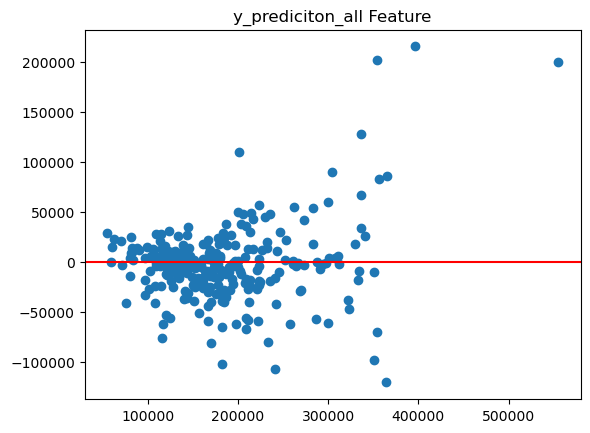

In [352]:
y_pred_allfeature = ann_allfeature.predict(X_test).flatten()
y_test_1d_allfeature = y_test.values.flatten()
plt.scatter(y_pred_allfeature, y_test_1d_allfeature - y_pred_allfeature)
plt.axhline(0, color='red')
plt.title("y_prediciton_all Feature")
plt.show()